## Base model for Students Outcome Predictor

### Description:
The Baseline Model is a Logistic Regression classifier. It is chosen for its simplicity, interpretability, and speed. In this project, the model's primary goal is to distinguish between students who will `Graduate` and those who will `Dropout`.

Priority Metric: Recall for the `Dropout` class, missing a student at risk (False Negative) is much more costly than accidentally flagging a successful student (False Positive). Therefore, I will evaluate the model primarily on its ability to capture as many true `dropouts` as possible.

In [32]:
# utils folder is in the root, the notebook cannot unless the root path is added to notebook.
############ import utils from if running from local machine ###########
import sys
sys.path.append('..')
from utils.data_utils import evaluate_classification_model, get_model_metrics, predict_with_threshold
###############################################################

################################################################
####################### GOOGLE COLAB RUN #######################
### Utils file is not available if running on Colab. I need to clone the repo to use the data_utils.py
# !git clone https://github.com/weslylaboy/student-outcome-predictor.git
# import sys
# sys.path.insert(0, '/content/student-outcome-predictor')
# from utils.data_utils import evaluate_classification_model, get_model_metrics, predict_with_threshold
###############################################################


import pandas as pd
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier


### 3.0 Load Data

The cleaned data was saved to `./data/processed/02.7_data_final.csv`. I will load this dataset for our modeling process.

In [2]:
##### import data file if runing on local machine
df = pd.read_csv('../data/processed/02.7_data_final.csv')

##################### GOOGLE COLAB ################################
### Data location is different if running on colab
# df = pd.read_csv('/content/student-outcome-predictor/data/processed/02.7_data_final.csv')
###################################################################
df.head()

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

***Interpretation:*** Imported data from the proccess data successfully, however, datatypes are not saved to the file. I will need to convert them to the appropriate types before modeling.

#### 3.1 Fix datatypes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

##### 3.1.1 Fix binary columns datatypes

In [5]:
int_cols = ['displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international', 'daytime_evening', 'age_at_enrollment', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_no_evaluations', 'cu2_credited', 'cu2_enrolled', 'cu2_evaluations', 'cu2_approved', 'cu2_no_evaluations', 'total_approved_units']
df[int_cols] = df[int_cols].astype('int8')

# additional engineered features
unknown_flags = [
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown', 'any_info_missing'
]
df[unknown_flags] = df[unknown_flags].astype('int8')

# target variable
df['target_encoded'] = df['target_encoded'].astype('int8')


df[int_cols].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   displaced                4424 non-null   int8 
 1   special_needs            4424 non-null   int8 
 2   debtor                   4424 non-null   int8 
 3   tuition_fees_up_to_date  4424 non-null   int8 
 4   gender                   4424 non-null   int8 
 5   scholarship_holder       4424 non-null   int8 
 6   international            4424 non-null   int8 
 7   daytime_evening          4424 non-null   int8 
 8   age_at_enrollment        4424 non-null   int8 
 9   cu1_credited             4424 non-null   int8 
 10  cu1_enrolled             4424 non-null   int8 
 11  cu1_evaluations          4424 non-null   int8 
 12  cu1_approved             4424 non-null   int8 
 13  cu1_no_evaluations       4424 non-null   int8 
 14  cu2_credited             4424 non-null   int8 
 15  cu2_

****Interpretation:**** Binary and integer columns have been converted to int8 for memory efficiency. The memory usage has been reduced to `86.5KB` from `1.6+MB`


##### 3.1.2 Fix Category columns datatypes

In [6]:
categorical_cols = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'prev_qualification',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# new engineered feature as category
df['age_group'] = df['age_group'].astype('category')
df.info()

df[categorical_cols].info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   category
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

***Interpretation:*** All category columns were converted to category datatype, including the new features created during feature engineering in step 2.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   category
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

*** Interpretation:*** All columns were updated to correct datatype, including the features that were created during the step feature engineerin in step 2.

### 3.2 Data Preparation: Remove Target Columns

In this step I will separate the features from the target columns. Also, I will filter out `Enrolled` students as these students will be used to deploy the model. So, the model will be trained using students with status `Graduate` or `Dropout`.

In [8]:
# create a copy excluding students with status Enrolled
df_baseline = df[df['target_encoded'] != 1].copy()

# define features and target
X = df_baseline.drop(['target', 'target_encoded'], axis=1)

# update the encoded values to mapping it to 0 and 1
# 0 = Dropout, 1 = Graduate to have a clean binary column.
y = df_baseline['target_encoded'].map({0:0, 2:1})


***Interpretation:*** Features and target were defined. Also, the target column was updated to a binary column with `0` for `Dropout` and `1` for `Graduate`.

In [9]:
X.shape, y.shape

((3630, 45), (3630,))

***Interpretation:*** The final dataset contains `3,630 rows`, `45 features`, and `1 target` variable.

### 3.3 Preprocessing and Pipeline

I will use ColumnTransformer to scale numeric features and encode categories. Then, create a pipeline for the base model.

In [10]:
# numerical features will be process with a StandardScaler
numeric_features = ['age_at_enrollment', 'cu1_grade', 'cu2_grade', 'total_approved_units', 'grade_progression']
# binary features
binary_features = ['debtor', 'tuition_fees_up_to_date', 'scholarship_holder', 'any_info_missing']
# One hot encoder
categorical_features = ['age_group']

preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
    ('categorical', OneHotEncoder(drop='first'), categorical_features)
])

# pipeline with LogisticRegression with a class_weight balance to hande the imbalance in Dropout vs Graduate
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

***Interpretation:*** A ColumnTransformer was created to encode numerical, binary, and categorical columns. The column transformer was passed to a pipeline with a LogisticRegression. The LogisticRegression was created with a params `class_weight=balanced` to handle the imbalance between `Graduate` and `Dropout`.

### 3.4 Training and Validation


In [11]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

#train model
baseline_pipeline.fit(X_train,y_train)

# evaluate prediction
y_pred = baseline_pipeline.predict(X_test)

print("Baseline Model: Logistic Regression")
print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))


Baseline Model: Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.86      0.82      0.84       284
    Graduate       0.89      0.91      0.90       442

    accuracy                           0.88       726
   macro avg       0.88      0.87      0.87       726
weighted avg       0.88      0.88      0.88       726



***Interpretation:*** The `accuracy` of the base model was `0.88`, this means the model correctly predict the outcome for `88%` of the students in the test set. For a baseline model, this is a good accuracy, but we can try to improve it by tuning the hyperparameters or using more advanced models.

The `precision` was `0.86` for `Dropout` students, so the model succesfully identified `86%` of students who `Dropout`. This means that there is low `False Positive` with a `14%`.

The `F1-Score` is `0.84` which confirms the model is good identifying `Dropouts`

The `recall` which is the main metric to use in this project, was `0.82`, meaning that of all students who `Dropout` the model actually identified `82%` of them. The model is missing `18%` of `Dropouts`, I will try to improve the model to avoid missing potential dropout to allow advisor to help students on time before they dropout.



### 3.5 Confusion Matrix

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                        display_labels=['Dropout', 'Graduate'],
                                        cmap='Blues')
plt.title('Baseline Confusion Matrix (Recall Focus)')
plt.show()

***Interpretation:*** The total of `True Positive` was `234`, the model correctly caught `234` dropouts.

The amount of `True Negative` was `404`, this is the amount of students who `Graduate` and the model correctly identified them.

The amount of `False Positive` was `38`, meaning the model incorrectly identified `38` students who `Graduate` as `Dropout`. In this project, this value doesn't have importance because I prefer to flag a students as at risk of `Dropout` than missing a real student who is actually at risk.

The `False Negative` is `50`, meaning the model missed `50` students who `Dropout`, reducing this number is the goal when training better models. I want to improve the model to avoid missing potential dropout to allow advisor to help students on time before they dropout.

### 3.6 Baseline Model Review

The Logistic Regression has successfully established a performance baseline for predicting student outcomes.  By focusing on binary classification (Graduate vs. Dropout) and using a balanced class weight, I will try to improve the recall `82%`.

## 4.0 Improving the baseline model

In this step I will try to improve the baseline model. First, I will include new features to the Logistic Regression model and compare the improvements. Then, I will try to improve the model by experimenting with different hyperparameters. I will use `GridSearchCV` to find the best hyperparameters for the model. The expectation is to improve the recall from `82%` which was the recall score from the baseline model.



### 4.1 Adding new features to the base model

To improve the model I will add academic performance and demographic data that showed importance during the EDA. The new features that I will use are: `cu1_approved`, `cu2_approved`, `course`, and `gender`.

Logistic Regression: With new Features: evaluation results
              precision    recall  f1-score   support

     Dropout       0.87      0.85      0.86       284
    Graduate       0.90      0.92      0.91       442

    accuracy                           0.89       726
   macro avg       0.89      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



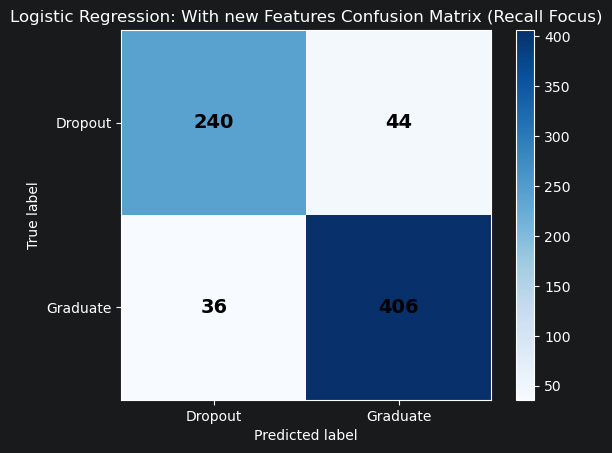

In [13]:
# numerical features will be process with a StandardScaler
numeric_features = ['age_at_enrollment', 'cu1_grade', 'cu2_grade', 'total_approved_units', 'grade_progression', 'cu1_approved', 'cu2_approved']
# binary features
binary_features = ['debtor', 'tuition_fees_up_to_date', 'scholarship_holder', 'any_info_missing', 'gender']
# One hot encoder
categorical_features = ['age_group', 'course']


preprocessor = ColumnTransformer(transformers=[
    ('numerical', StandardScaler(), numeric_features),
    ('binary', 'passthrough', binary_features),
    ('categorical', OneHotEncoder(drop='first'), categorical_features)
])


# pipeline with LogisticRegression with a class_weight balance to hande the imbalance in Dropout vs Graduate
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])

lr_model.fit(X_train,y_train)

# evaluate prediction
y_pred = lr_model.predict(X_test)

evaluate_classification_model(y_test, y_pred, target_names=['Dropout', 'Graduate'],                          model_name= "Logistic Regression: With new Features")




***Interpretation:*** Adding new features that showed importance during EDA slightly improved the model. The `precision` and `accuracy` scores increased by only `1%`, the `f1` score on `Dropouts` increase from `84%` to `86%`.

The `recall` score on `Dropouts` increase from `82%` to `85%`. This is a good improvement, but the model still has room for improvement.

From the Confusion Matrix, I can see that the number of false negatives has decreased from `50` to `44`, and the amount of correctly identified as `Droptout` from `234` to `240`. This is a good sign of improvement, even when the number of false positives increased, because I prefeer misclassifying a student as risk than missing a student that is actually at risk.



### 4.2 GridSearchCV Hyperparameter Tuning

In [14]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'liblinear']
}

grid_search = GridSearchCV(
    lr_model,
    param_grid,
    cv=5,
    scoring='recall',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train,y_train)

# best model
best_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


***Interpretation:*** The `GridSearchCV` hyperparameter tuning was performed to find the best combination of hyperparameters for the logistic regression model. I tested 5 values for `C (0.01, 0.1, 1,10,100)` and 2 types of `solver (libfgs, liblinear)` for a total of 10 combinations, with 5 fold cross-validation for a total of 50 training cycles.

The best parameter found were the following:
- `C = 0.01`, the smaller values means stronger regularization, meaning that a more constrained model perform better at identifying dropouts.
- `penalty = l2`, standard Ridge regularization, it penalized large coefficients across all features.
- `solver = liblinear`, this solver is suitable for small datasets or l2 penalties on binary classification, and is known for its efficiency.

#### 4.2.1 Evaluating the Best Logistic Regression Model

In [ ]:
evaluate_classification_model(y_test, best_model.predict(X_test), model_name='Best Logistic Regression Model')

**Interpretation:** Comparing the GridSearchCV results with the model with new features, I can see the new model caught `240` Dropout for a `85%` recall while the model with new features caught `229` Dropout for a `81%` recall. The recall dropped by a `4%`, this could have happened because of the strong regularization `C=0.01`, this makes the model more conservative to prevent overfitting.

While the recall for the `GridSearchCV` model recall was less than the first model, I would still choose the `GridSearchCV` model as the better model because it was cross-validated 50 times to ensure the model performs better across different students.

Both models predict `Dropout` only if the probability is above `50%`. This means that if the model is `51%` sure a student will graduate, the model will label them as `Graduate`. In my case, classifying a student as at risk when they are not is less harmful than missing a student actually at risk. Since I want to be safe of not missing a possible dropout, I will lower the threshold to `0.4`, this means that the model needs to predict a probability of `60%` of Graduate to classifying them as `Graduate` capturing more `Dropout`.

### 4.3 Apply a custom threshold to the model

Currently, the model default probability threshold is `0.5`. I will lower the threshold to `0.4` to capture more `Dropout` students. This means that for a student to be flagged as `Graduate`, it needs to have a probability of graduation `>60%`, else it will be flagg as a student as risk of `Dropout`.

Logistic Regression with Custom Threshold: evaluation results
              precision    recall  f1-score   support

     Dropout       0.81      0.86      0.83       284
    Graduate       0.91      0.87      0.89       442

    accuracy                           0.87       726
   macro avg       0.86      0.86      0.86       726
weighted avg       0.87      0.87      0.87       726



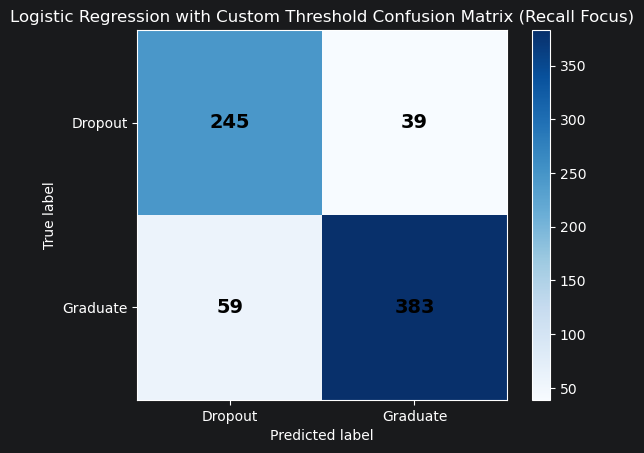

In [16]:
# 0 is Dropout, 1 is Graduate. probs = probability of being Graduate
probs = best_model.predict_proba(X_test)[:, 0]

# Set a lower threshold for Dropout to catch MORE. A student needs a 60% chance of graduating to be labeled 'Graduate'
# If they have a 55% chance of graduating, they will now be flagged as 'Dropout'
custom_threshold = 0.4
y_pred_custom = (probs <= custom_threshold).astype(int)

evaluate_classification_model(y_test, y_pred_custom, model_name='Logistic Regression with Custom Threshold')

***Interpretation:*** After updating the threshold to `0.4` the model needs to be more than `60%` sure to say the student will `Graduate` instead of the default `0.5`. By using `0.4` threshold, the recall for dropouts increase from `81%` to `86%`. The model is better with the new threshold as it captures more `Dropouts`.

From the Confusion Matrix above, I can confirm there are `39` Dropouts that the models is not capturing.

### 4.4 Save Logistic Model results

In this step, I will define a variable, `results_models_metrics` that will hold all the metrics for each model tested. This variable will be append with the results of the method `get_model_metrics` which results the metrics for the current tested model.


In [17]:
results_models_metrics = []

results_models_metrics.append(get_model_metrics(y_test, y_pred_custom, 'Logistic Regression'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.865,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866


***Interpretation:*** The Logistic Regression model `accuracy` with a threshold of `0.4` for `Dropout` was `86.5%`, this means the model correctly predicted the outcome for `86.5%` of the students.

The `precision` was `80.59%` for `Dropout` students, when the model flags a students as `Dropout`, it is correct `80.59%` of the time. This means there are `19.41%` of `False Positives`.

The `recall` which is the main metric in this project, was `86.27%`, so the model is successfully identifying `86.27%` of all students who actually dropped out. This means the model is missing `13.73%` of `Dropouts`. I will try to improve this number using other classifications models.

The `F1-Score` is `83.33%` for `Dropout` which confirm the model has a good balance between precision and recall for identifying students at riks of `Droptout`

For `Graduate` students, the `precision` was `90.76%` and `recall` was `86.65%`, indicating the model is also reliable to predict students who will graduate.


## 5.0 Decision Tree

After improving the Logistic Regression model, I will test another a Decision Tree classifier. Logistic Regression is useful as a baseline because it is simple, fast, and interpretable, but it may not fully capture non linear relationships between student features and `Dropout` risk.

A Decision Tree is a supervised learning model that makes predictions by splitting the data into smaller groups based on feature values. This makes it easier to understand how the model reaches a prediction because the decision process can be visualized as a tree.

The purpose of this model is to test whether I can improve the prediction of students outcomes from the Logistic Regression.



### 5.1 Decision Tree Preprocessor and Pipeline

One benefits of Decision Tree is that the model is interpretable, however, my initial preprocessor is using Standard Scaler. If I reuse the same preprocessor to build the Decision Tree model, the split rules in the model will have standardized values intead of the original units. So, I will avoid scalling and build a new preprocessor without Standard Scaler.

In [ ]:

# create a new preprocessor without numeric scaling
dt_preprocessor = ColumnTransformer([
    ('numerical', 'passthrough', numeric_features),
    ('binary', 'passthrough', binary_features),
    ('categorical', OneHotEncoder(drop='first'), categorical_features)
])

dt_pipeline = Pipeline([
    ('preprocessor', dt_preprocessor),
    ('dt_model', DecisionTreeClassifier(random_state=42))
])

dt_pipeline

***Interpretation:*** A new pipeline was created for the Decision Tree Classifier. In this case, the numerical features was not scaled because is not necessary for Decision Tree Classifier.

## 5.2 Training the Decision Tree Model

In this section, I will train a Decision Tree classifier and compare its performance against the Logistic Regression model. The main goal is to see whether the Decision Tree can improve recall for the `Dropout` class while maintaining overall accuracy.


In [ ]:
# train the model with the same
dt_pipeline.fit(X_train, y_train)

# Get all default parameters
params = dt_pipeline.get_params()
for param, value in sorted(params.items()):
    print(f"{param}: {value}")


***Interpretation:*** The default Decision Tree has the following characteristic:
- max_depth: None:
- min_samples_split: 2
- class_weight: None
- criterion: gini

A `max_depth = None` means that the tree will continue to expand until all leaves are pure or contain fewer than `min_samples_split` which is `2`. This could lead to overfitting where the model memorizes the training noise.

The `class_weight = None` means the Decision Tree is not balancing the imbalance class. At the beginning, I saw that there were an imalance between `Dropout` and `Graduate` students, this balancing is turned off for this model because of the `class_weight = None`. This may cause biased toward the majority class which is `Graduate` in this case.

In the next step I will evaluate the performance, but I expect a poor performance given the default parameters discussed above.

## 5.3 Evaluate the Decision Tree Model

I have created a custom function called `predict_with_threshold` which will predicts labels based on a custom probability threshold and evaluates the model. This same function will be used to evaluate all other models.

In [ ]:
# evaluate
y_pred_dt = predict_with_threshold(dt_pipeline, X_test, y_test, threshold=0.4, model_name='Decision Tree')

***Interpretation:*** The Decision Tree model performed relatively well with a custom threshold of `0.4`. The model correctly identifies `236 Dropout` students and `396 Graduate` students, while making only `48 False Dropout` and `46 False Graduate`. The accuracy of `0.87` and recall of `0.83` for `Dropout` show this is performing well and is balance.


In [22]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_dt, 'Decision Tree'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.8650,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866
Decision Tree,0.8705,0.8369,0.8310,0.8339,0.8919,0.8959,0.8939


### 5.3.4 Comparing Decision Tree with Logistic Regression

***Interpretation:*** The Decision Tree model performed well, comparing it with the Logistic Regression model, the accuracy are close for both model, for the Logistic Regression was `86.5%` while the Decision Tree was `87.05%` showing minimal improvements. The `recall` for the `Dropout` class was lower for the Decision Tree model with a `83.10%` while the Logistic Regression had `86.27%`.

The model are similar in some metrics, but the `recall` for `Dropout` was lower in the Decision Tree. I will tune the model with `GridSearchCV` and compare it against Logistic Regression and other baselines to see whether performance improves.

## 5.4 Tuning Decision Tree Model

In this section, I will tune the Decision Tree model with `class_weight = balance` to find the best hyperparameter. I will use `GridSearchCV` to find the best hyperparameters, this will help the tree capture more patterns without overfitting the model.

In [23]:
# parameter grid
param_grid = {
    'dt_model__max_depth': [3, 5, 7, 10,15, 20, 25,40, None],
    'dt_model__min_samples_split': [2, 5, 10, 20, 25, 30, 40, 50],
    'dt_model__min_samples_leaf': [1, 2, 5, 10, 15, 10, 25, 30],
    'dt_model__max_features': ['sqrt', 'log2', None],
    'dt_model__criterion': ['gini', 'entropy']
}

dt_pipeline = Pipeline([
    ('preprocessor', dt_preprocessor),
    ('dt_model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Set up grid search
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_dt_model = grid_search.best_estimator_
print(grid_search.best_score_)



Best parameters: {'dt_model__criterion': 'entropy', 'dt_model__max_depth': 3, 'dt_model__max_features': None, 'dt_model__min_samples_leaf': 25, 'dt_model__min_samples_split': 2}
0.9399993598053807


***Interpretation:*** For the tuned model using `GridSearchCV` the best criterion was `entropy`, it was found to be performing better when using `class_weight = balanced`. The grid found that `max_depth` with `3` levels generalize better than deeper trees. The best value for `min_samples_leaf` was found to be `25` and the `min_samples_split` value was found to be `2`. The best score was `0.9499`.

## 5.5 Tuned Decision Tree Evaluation

Now I will evaluate the tuned Decision Tree model to see how it performs against the test set.

In [ ]:
y_pred_dt = predict_with_threshold(best_dt_model, X_test, y_test, threshold=0.4, model_name='Tuned Decision Tree')


***Interpretation:*** The tuned Decision Tree model performed slighly better compared to the default Decision Tree model. For the `Dropout` class, the precision was `0.82`, the recall `0.85`, and `f1-score` was `0.84`. The `acurracy` was `87%`, same as the default model, no improvements in the `accuracy`. This model correctly identified only `242` of `Dropout` students, and misclassified `42` students as `Graduate`. The model correctly identified `390 Graduates` and misclassified `52 Graduate` as `Dropout`.


In [25]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_dt, 'Decision Tree (Tuned)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.8650,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866
Decision Tree,0.8705,0.8369,0.8310,0.8339,0.8919,0.8959,0.8939
Decision Tree (Tuned),0.8705,0.8231,0.8521,0.8374,0.9028,0.8824,0.8924


***Interpretation:*** A Decision Tree model did not see improvements after being tuned. Both default and tuned model performed similarly. I will use `SMOTE` to see how it improves the Decision Tree model.

## 5.6 Using SMOTE with Decision Tree

The Decision Tree models have not performed well. I will use `SMOTE` to handle class imbalance, `SMOTE` may help the tree learn better split for the minority class. In practive, this can improve recall for the imbalance class `Dropout`. Also, I will perform `GridSearchCV` using `SMOTE` to see how it improves from the previous tuned Decision Tree model.

In [26]:
dt_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('dt_model', DecisionTreeClassifier(random_state=42))
])

# Set up grid search
grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_dt_model = grid_search.best_estimator_
print(grid_search.best_score_)

Best parameters: {'dt_model__criterion': 'entropy', 'dt_model__max_depth': 5, 'dt_model__max_features': None, 'dt_model__min_samples_leaf': 5, 'dt_model__min_samples_split': 20}
0.9530145164129895


***Interpretation***: The best Decision Tree with `SMOTE` uses `entropy` as the splitting `criterion`, a `maximum_depth` of `5`, a minimum of `5` samples per leaf, and a minimum of `20` samples required to split. These settings make the tree more controlled and less likely to overfit. The cross-validation score of `0.9530` indicates that the tuned tree performed very well across the validation folds.

### 5.7 Evaluating Tuned SMOTE Decision Tree

In [ ]:
y_pred_dt = predict_with_threshold(best_dt_model, X_test, y_test, threshold=0.4, model_name='Decision Tree (SMOTE)')

results_models_metrics.append(get_model_metrics(y_test, y_pred_dt, 'Decision Tree (SMOTE)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')



***Interpretation:*** The Decision Tree with `SMOTE` did not improved compared to the tuned Desicion Tree model. It correcly identifies `228 Dropout` students and `424 Graduates` students, while misclassifying `56 Dropout` as `Graduate` and `18 Graduate` as `Dropout`. The `accuracy` was `90%`, and a `recall` of `80%` for the `Dropout` class.

While the `accuracy` improved by `3%`, the `recall` for `Dropout` decreased, causing to miss students at risk of `Dropout`. This suggests that `SMOTE` did not improve the model enough to make it suitable as the final classifier.


## 6.0 K-Nearest Neighbors (KNN)

The next classifier I will test is KNN. This is a supervised learning algorithm that classifies new data points based on the majority class among their `k` closest neightbors in the training set. For this model, I will need to standardize the numerical features.

### 6.1 KNN Pipeline

I will reuse the same preprocessor used for the Logistic Regression. This preprocessor was already defined with StandardScaler for numerical features, OneHotEncoder for categorial features. This preprocessor will be used to build a pipeline for the KNN model. First, I will build the model with the defaults parameters and compare it to the Logistic Regression model.

In [ ]:
# pipeline with default kNN
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn_model', KNeighborsClassifier())  # Uses default n_neighbors=5
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = predict_with_threshold(knn_pipeline, X_test, y_test, threshold=0.4, model_name='K-Nearest Neighbors')



***Interpretation:*** The basic KNN model performed poorly compared to previous model, for the `Dropout` class the `precision` was `0.92` while for the `Graduate` class it was `0.87`. The `accuracy` was `88%`. The `recall` for `Dropout` was `0.77`. This model misses more `Dropout` and missclassify them as `Graduate`. This model is not good and it will need to be tuned.

### 6.2 Tuned K-Nearest Neighbors

In this step, I will tune the KNN classifier using `GridSearchCV`. The grid will have the following hyperparameters: `n_neightbors` which is the number of neightbors to vote, `metrics` for distance calculation, `p`, and `weights`.

In [29]:
# parameter grid for kNN
param_grid = {
    'knn_model__n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 33, 40, 55],  # number of neighbors
    'knn_model__weights': ['uniform', 'distance'],  # how to weight neighbors
    'knn_model__metric': ['minkowski', 'euclidean'],  # distance metric
    'knn_model__p': [1, 2]  # p=1 (Manhattan), p=2 (Euclidean)
}

# Set up GridSearchCV
grid_search_knn = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='recall',  # for imbalanced multiclass
    n_jobs=-1
)

# Fit grid search
grid_search_knn.fit(X_train, y_train)

print("Best kNN parameters:", grid_search_knn.best_params_)
print("Best CV score:", grid_search_knn.best_score_)

# Get best model
best_knn_model = grid_search_knn.best_estimator_

Best kNN parameters: {'knn_model__metric': 'minkowski', 'knn_model__n_neighbors': 33, 'knn_model__p': 2, 'knn_model__weights': 'uniform'}
Best CV score: 0.9852851266785103


***Interpretation:*** The best KNN model uses `n_neightbors = 33`, this means the model makes each prediction by looking at a group of `33` of similar students. The `weights = uniform` meaning each `33` neightbors contributes equally to the final vote, the prediction depends on the majority class among the `33` nearby students. The parameter `metric = minkowski (p=2)` means the model is using Euclidean distance to measure similarity between students.  The cross-validation score was `0.9852`, suggesting the model performs well and generalizes reasonably accross subsets of the data.

Next, I will evaluate the model using the test data.

### 6.3 Evaluating Tuned K-Nearest Neightbors

In [ ]:
y_pred_knn = predict_with_threshold(best_knn_model, X_test, y_test, threshold=0.4, model_name='K-Nearest Neighbors (Tuned)')


***Interpretation:*** The tuned KNN model did not improved the results. Although the model identified `220` students who actually `Dropout`, it also misclassified `64 Dropout` students as `Graduate` and `20 Graduate` students as `Dropout`. The `precision` for the `Dropout` class was `0.92`, the `recall` was `0.77`. This was not a good model despite the high cross-validation score of `98.52%` in the training set. The model was not an improvement from the default version of the model.

In [31]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_knn, 'K-Nearest Neighbors (Tuned)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.8650,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866
Decision Tree,0.8705,0.8369,0.8310,0.8339,0.8919,0.8959,0.8939
Decision Tree (Tuned),0.8705,0.8231,0.8521,0.8374,0.9028,0.8824,0.8924
Decision Tree (SMOTE),0.8981,0.9268,0.8028,0.8604,0.8833,0.9593,0.9197
K-Nearest Neighbors (Tuned),0.8843,0.9167,0.7746,0.8397,0.8683,0.9548,0.9095


***Interpretation:*** The `accuracy` of `88.43%` and `recall` of `77.46%` for the `Dropout` class indicate that this model does not separate the two classes as well as the default configuration model, so it is not a suitable candidate for the final model.

I will try to use `SMOTE` technique to see how the model improves.

### 6.4 Using SMOTE for K-Nearest Neighbors Classifier

Since KNN relies on nearby examples, if the dataset is imbalance, the majority class dominates the local neighborhood. SMOTE adds synthetic minority points, which can make the local neighborhood more balanced and help KNN recognize `Dropout` students better.

I will do a `GridSearchCV` to see if the model can be improved handling the imalance class with `SMOTE`.

In [32]:
knn_smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('knn_model', KNeighborsClassifier())
])

# parameter grid for kNN
param_grid = {
    'knn_model__n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25, 33, 40, 55],  # number of neighbors
    'knn_model__weights': ['uniform', 'distance'],  # how to weight neighbors
    'knn_model__metric': ['minkowski', 'euclidean'],  # distance metric
    'knn_model__p': [1, 2]  # p=1 (Manhattan), p=2 (Euclidean)
}

# Set up GridSearchCV
grid_search_knn = GridSearchCV(
    knn_smote_pipeline,
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='recall',  # for imbalanced multiclass
    n_jobs=-1
)

# Fit grid search
grid_search_knn.fit(X_train, y_train)

print("Best kNN parameters:", grid_search_knn.best_params_)
print("Best CV score:", grid_search_knn.best_score_)

# Get best model
best_knn_model = grid_search_knn.best_estimator_

Best kNN parameters: {'knn_model__metric': 'minkowski', 'knn_model__n_neighbors': 55, 'knn_model__p': 1, 'knn_model__weights': 'distance'}
Best CV score: 0.9733967126006305


***Interpretation:*** This best KNN model with `SMOTE` uses `55` neighbors, and `weight = discance`. This means the model predicts eachs student outcome by considering a large neighborhood of similar students. The cross-validation score of `0.9734` suggests that this configuration performs well. I will evaluate with test set to see if the model generalizes well.

### 6.6 Evaluating SMOTE KNN model

In [ ]:
y_pred_knn = predict_with_threshold(best_knn_model, X_test, y_test, threshold=0.4, model_name='K-Nearest Neighbors (SMOTE)')


***Interpretation:*** The KNN model with `SMOTE` achieved a much higer `Dropout` recall of `0.80` while for the `Graduate`, the `recall` was `0.94`. This means that the model is correctly identifying `94%` of `Graduate`. The `accuracy` improved to a `89%` compared to the defaul KNN configuration. This suggest that adding `SMOTE` helped the model handle class imbalance and improve generalization performance.

In [34]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_knn, 'K-Nearest Neighbors (SMOTE)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.8650,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866
Decision Tree,0.8705,0.8369,0.8310,0.8339,0.8919,0.8959,0.8939
Decision Tree (Tuned),0.8705,0.8231,0.8521,0.8374,0.9028,0.8824,0.8924
Decision Tree (SMOTE),0.8981,0.9268,0.8028,0.8604,0.8833,0.9593,0.9197
K-Nearest Neighbors (Tuned),0.8843,0.9167,0.7746,0.8397,0.8683,0.9548,0.9095
K-Nearest Neighbors (SMOTE),0.8884,0.9012,0.8028,0.8492,0.8816,0.9434,0.9115


***Interpretation:*** The KNN model using `SMOTE` performed similarly to the tuned Decision Tree model. The metrics `accuracy` for the `SMOTE` KNN model is the higher so far of all tested model with `88.84%`. This model seem like a good candidate for the final model.

Next, I will try another classifier, to see if I can get better results.

## 7.0 Support Vector Machine (SVM)

I will now test a Support Vector Machine classifier. SVM is a supervised learning algorithm that finds the decision boundary that best separates `Dropout` and `Graduate` students. This makes it a useful model to compare against Logistic Regression, especially this dataset which is imbalance.
+1

### 7.1 SVM Pipeline

SVM classifier is sensitive to a feature scale, so I will use the same preprocessor which was defined with StandardScaler for numerical features, OneHotEncoder for categorial features.

Also, I will use `probability = True` so I can use the custom threshold of `0.4`.

In [ ]:
# pipeline with default SVM
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm_model', SVC(random_state=42, class_weight='balanced', probability=True))
])

svm_pipeline.fit(X_train, y_train)

y_pred_svm = predict_with_threshold(svm_pipeline, X_test, y_test, threshold=0.4, model_name='Support Vector Machine')



***Interpretation:*** The default SVM performed well but not as good as previous model. It identified `238 Dropout` students correctly and misclassified `30 Graduate` students as `Dropout`, resulting in an accuracy of `90%` and a `recall` of `84%`. This model is still missing more `Dropout` compared to previous model, I need to tune this model and compare it again.

### 7.2 Tuning Support Vector Machine

In this step, I will use `GridSearchCV` to find the best hyperparameter for the `SVM` model. One parameter is the `kernel` chooses the shape of the decision boundary which can be `linear` for straing line boundary or `rbf` for non linear boundary. Another, is `C` which controls regularization, a small value makes it more flexibel and tolerand of mistakes, while large values force the model to fit the training data more closely. The `gamma` parameter controls how much influence a single training point has.

In [36]:
# svm grid
param_grid = {
    'svm_model__kernel': ['linear', 'rbf'],
    'svm_model__C': [0.001, 0.01, 0.1, 1,5, 7, 10, 20, 35, 50, 75, 100, 135, 150],
    'svm_model__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

print(f'Best params: {grid_svm.best_params_}')
print(f'Best score: {grid_svm.best_score_}')

# Get best model
best_svm_model = grid_svm.best_estimator_

Best params: {'svm_model__C': 0.001, 'svm_model__gamma': 'scale', 'svm_model__kernel': 'rbf'}
Best score: 1.0


***Interpretation:*** The `GridSearchCV` found that the best `kernel` was `rbf` which was expected for non linear dataset. It also found the best `C` was `0.001` which means the model is very conservative and regularized, and best `gamma` was `scale`. The validation score of `1.0` suggest the model achieved perfect recall during cross-validation. I will test against the test data to compare agains other models.

### 7.3 Evaluating the Support Vector Machine Model

In [ ]:
y_pred_svm = predict_with_threshold(best_svm_model, X_test, y_test, threshold=0.4, model_name='Support Vector Machine')

results_models_metrics.append(get_model_metrics(y_test, y_pred_svm, 'Support Vector Machine (Tuned)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

***Interpretation:*** The tuned SVM model achieved an `accuracy` of `60.88%` but this is misleading because it predicted every student as `Graduate`. As a result, it failed to identify any `Dropout` students, giving a recal of `0.00` for the `Dropout` class. This can happen when the classes are not well separated, or when one class is more common, or when the choses threshold is not low enough to recover `Dropout` predictions.

I will use `SMOTE` to balance the classes and apply `GridSearchCV` to find the best SVM hyperparameters.


## 7.4 Using SMOTE with Support Vector Machine

In this step, I will perform a `GridSearchCV` with `SMOTE` to balance classes with the Support Vector Machine classifier.

In [38]:

smote_svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
])

# for linear, gamma is irrelevant, using two separate grid to avoid invalid combinations
param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.01, 0.1, 1, 5, 7, 10, 15, 20]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.01, 0.1, 1, 5, 7, 10, 15, 20],
        'svm__gamma': ['scale', 'auto']
    }
]

grid_smote_svm = GridSearchCV(
    estimator=smote_svm_pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_smote_svm.fit(X_train, y_train)

print(grid_smote_svm.best_params_)
print(grid_smote_svm.best_score_)

# Get best model
best_smote_svm_model = grid_smote_svm.best_estimator_

{'svm__C': 0.01, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
0.9609449272578864


***Interpretation:*** The grid found the best hyperparameters for the SVM model using `SMOTE` are: `C=0.01`, and `gamma = auto`, and `kernel = rbf`, achieving a validation score of `89.55%`.

## 7.4 Evaluating SMOTE Support Vector Machine

In [ ]:
y_pred_svm = predict_with_threshold(best_smote_svm_model, X_test, y_test, threshold=0.4, model_name='Support Vector Machine')

results_models_metrics.append(get_model_metrics(y_test, y_pred_svm, 'Support Vector Machine (SMOTE)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

***Interpretation:*** The tuned model performance was similar to the default setting model. The `accuracy` was `86%`, the `recall` for `Dropout` was `0.84`. The model did not improved after the `GridSearchCV` hyperparameter tuning.

So far, the leading models are Logistic Regression, tuned Decision Tree using SMOTE, and KNN using SMOTE. All these three leading models are performing similarly with a `recall` for `Dropout` around `83-86%`.

I will next build a ensemble method to see how it performs compared to the leading models.

## 8.0 Ensemble Model

So far, the leading classifiers are Logistic Regression, Decision Tree, and KNN. In this step, I will use an ensemble model. An ensemble model combines multiple models to improve robustness and usually performs better than a single classifier. For this case, an ensemble can help because one model may capture linear patters, another may capture nonlinear patters, and voting or boosting can reduce the weaknesses any of the models may have.

### 8.1 Random Forest

After testing Logistic Regression, Decision Tree, K-Nearest Neighbors, and SVM, I will now train a Random Forest classifier. Random Forest is an ensemble method that builds multiple decision trees and merges their predictions to produce a more accurate and stable result.


### 8.1.1 Baseline Random Forest

Since Random Forest is a tree-based model, **feature scaling is not required**. I will reuse the same preprocessor built for the Decision Tree `dt_preprocessor` that passes numerical features through without scaling. This keeps the feature values in their original units, which also makes feature importance easier to interpret.


In [ ]:
rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', dt_preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])

# Train the Random Forest pipeline
rf_pipeline.fit(X_train, y_train)

# Print all default parameters for reference
params = rf_pipeline.get_params()
for param, value in sorted(params.items()):
    print(f"{param}: {value}")



***Interpretation:*** The Random Forest baseline was trained using the default configuration with a custom preprocessing pipeline. This provided a simple baseline model before hyperparameter tuning, this will allow to evaluate how well a standard ensemble model performs on the dropout prediction task.

### 8.1.2 Evaluating Baseline Random Forest

In [ ]:
y_pred_rf = predict_with_threshold(rf_pipeline, X_test, y_test, threshold=0.4, model_name='Random Forest (Baseline)')

***Interpretation:*** This is a string baseline. The Random Forest is performing almost as well as the previous tuned classifiers. This model achieved `90% accuracy` with balanced performanced across both classes. The `recall` for the `Dropout` class was `0.82` and the precision `0.90`. It correctly identified most `Dropout` students, but it still missed `50` students, which is important because those are the students most likely to need intervention.

## 8.2 Random Forest with SMOTE

Following the same pattern used with the Decision Tree and KNN models, I will now apply **SMOTE**  to address the class imbalance between `Dropout` and `Graduate` students during training.


In [ ]:
rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', dt_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# Train
rf_smote_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf_smote = rf_smote_pipeline.predict(X_test)

# Evaluate
evaluate_classification_model(y_test, y_pred_rf_smote, target_names=['Dropout', 'Graduate'],
                               model_name='Random Forest (SMOTE)')

***Interpretation:*** Adding `SMOTE` to the Random Forest produced performance that was very similar to the baseline model Random Forest. It slightly improved precision for the `Dropout` class and reduced false `Dropout` predictions among `Graduate` students, but it did not improve `Dropout` recall or overall accuracy. The model misses `2` more `Dropout` than the baseline Random Forest.

Next, I will perform `GridSearchCV` to find the best hyperparameters for the Random Forest with `SMOTE`.

## 8.3 Hypertuning Random Forest with SMOTE

With `GridSearchCV`, I will find the best hyperparameter for the Random Forest model, then I will compare with Random Forest model with default configuration.

In [19]:
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20, 30],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
}

grid_rf_smote = GridSearchCV(
    estimator=rf_smote_pipeline,
    param_grid=param_grid_rf,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_rf_smote.fit(X_train, y_train)

print(f'Best params: {grid_rf_smote.best_params_}')
print(f'Best Score: {grid_rf_smote.best_score_}')

best_rf_smote_model = grid_rf_smote.best_estimator_

Best params: {'rf__max_depth': 20, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}
Best Score: 0.9513212016453002


***Interpretation:*** The tuned Random Forest with `SMOTE` achieved a `0.952` score using `200 trees`, a `maximum_depth = 20`, and the default classification setting of `max_features='sqrs'`. This suggest the model captured useful patter in the data while maintaining strong generalization. Next, I will evaluate the model again the test set.

### 8.4 Evaluating Tuned Random Forest

Now, I will evaluate the final Random Forest model with `SMOTE` and compare it to previous model.

Random Forest + SMOTE (Tuned): evaluation results
              precision    recall  f1-score   support

     Dropout       0.93      0.81      0.87       284
    Graduate       0.89      0.96      0.92       442

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.90      0.90       726



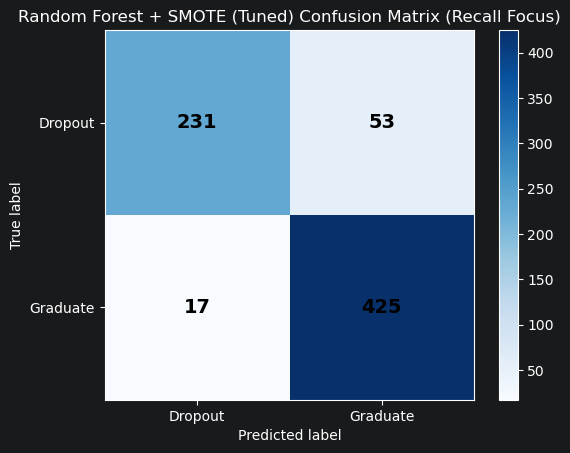

In [20]:
y_pred_rf_smote = best_rf_smote_model.predict(X_test)

evaluate_classification_model(
    y_test,
    y_pred_rf_smote,
    model_name="Random Forest + SMOTE (Tuned)",
    target_names=['Dropout', 'Graduate']
)

***Interpretation:*** For the `Dropout` class the `precission` was `0.93`, the `recall` was `0.81`, and the `accuracy` was `0.90`. Comparing to the baseline Random Forest, the new model missclassified `53 Dropout` as `Graduate` while the baseline Random Forest misclassified `52 Dropout` a difference of just `1`. However, the new model correcly classified `425 Graduate` while the baseline Random Forest correctly classified `422 Graduate`. The tuned model correcly classified `231 Dropout` while the baseline correctly classified `232 Dropout`, not much difference in this model.

### 8.4.1 Evaluate using threshold


In [ ]:
y_pred_rf_smote = predict_with_threshold(best_rf_smote_model, X_test, y_test, threshold=0.4, model_name='Random Forest + SMOTE (Tuned)')

results_models_metrics.append(get_model_metrics(y_test, y_pred_rf_smote, 'Random Forest + SMOTE (Tuned)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

***Interpretation:*** Using the threshold of `0.4`, the model improved the `recall` of `Dropout` to `0.85` compared to using the defaul threshold. Now it correctly identified `242 Dropout` instead of `231 Dropout`, it missed `42 Dropout` while the previous model missed `53 Dropout`. This is clearly an improvement.

### 8.5 RandomizedSearchCV Hyperparameter Tuning

`GridSearchCV` tests every combination of hyperparameters, which becomes computationally expensive as the search grid grows. **`RandomizedSearchCV`**  samples a fixed number of random combinations from the parameter distributions, making it much faster while still finding strong hyperparameters.

Random Forest has more hyperparameters to tune `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `class_weight`. A full grid would require thousands of fits.



### 8.5.1 Define Distributions

In [27]:
# Define the parameter distributions to sample from
param_distributions = {
    'rf__n_estimators': randint(50, 500), # distribution from 50 and 500 trees
    'rf__max_depth': [None, 5, 10, 15, 20, 30], # None = unlimited depth
    'rf__min_samples_split': randint(2, 30),# Min samples to split a node
    'rf__min_samples_leaf': randint(1, 20), # Min samples at a leaf node
    'rf__max_features': ['sqrt', 'log2', None],# Features to consider per split
    'rf__class_weight': [None, 'balanced'],# Handle class imbalance
}

print("Parameter distributions defined.")
print(f"Sampling space:")
for param, dist in param_distributions.items():
    print(f"  {param}: {dist}")

Parameter distributions defined.
Sampling space:
  rf__n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x30451f820>
  rf__max_depth: [None, 5, 10, 15, 20, 30]
  rf__min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x30451fce0>
  rf__min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x30642ec30>
  rf__max_features: ['sqrt', 'log2', None]
  rf__class_weight: [None, 'balanced']


**Interpretation:** The parameter distributions define the **search space** for `RandomizedSearchCV`. In this case I used `scipy.stats.randint` which can generate continuous distributions that allow the search to test a much wider range of values with the same number of iterations. The grid was:

- `n_estimators`: sampled from a wide range (50–500) to find the minimum number of trees that results in stable performance.
- `max_depth=None` is included alongside capped values, unlimited depth may overfit, but is worth testing alongside constrained depths.
- `max_features`: `sqrt` (default) is the most common choice, but `log2` and `None` which use all features are also tested.
- `class_weight='balanced'` makes the model penalize `Dropout` misclassifications more heavily, which should improve `recall` for the priority class.


In [30]:
random_search_rf = RandomizedSearchCV(
    rf_smote_pipeline,
    param_distributions=param_distributions,
    n_iter=50, # Number of random combinations to try
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_rf.fit(X_train, y_train)

print(f"Best Parameters:{random_search_rf.best_params_}")
print(f"Best CV Recall (Dropout): {random_search_rf.best_score_:.4f}")

best_rf_random = random_search_rf.best_estimator_


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters:{'rf__class_weight': None, 'rf__max_depth': 10, 'rf__max_features': None, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 11, 'rf__n_estimators': 94}
Best CV Recall (Dropout): 0.9502


***Interpretation:*** `RandomizedSearchCV` found a Random Forest configuration that achieved a `recall` for `Dropout` of `0.9802` during cross-validation. The best model used `94 trees`, a `maximum_depth` of `10` and `split_samples` of `11`. This suggests a good generalization. I will evaluate this model against the test data.

### 8.5.2 Evaluating the model

In [ ]:
# Predict on the test set
y_pred_rf_random = best_rf_random.predict(X_test)

# Evaluate using the shared utility function
evaluate_classification_model(y_test, y_pred_rf_random, target_names=['Dropout', 'Graduate'], model_name='Random Forest (RandomizedSearchCV)')


***Interpretation:*** This tuned Random Forest is slightly better at finding `Graduate` students, but slightly worse at finding `Dropout` students compared with the tuned version of Random Forest using `GridSearchCV`. For the `Dropout` class the `precision` was `0.93`, the `recall` was `0.81`. For the `Graduate` class the `precision` was `0.89`, a strong indication of correctly prediction `Graduate` students. This model correctly predicted `229 Dropout` but missed `55 Dropout`, also it incorrectly predicted `16 Dropout` while correctly predicted `426 Graduate` students.

The tuned version using `RandomizedSearchCV` did not improve overal `accuracy` and did not improve `Dropout` recall either. Since my goal is to identify students at risk of `Dropout` the Random Forest with `SMOTE` is better than this tuned version.

In [ ]:
y_pred_rf = predict_with_threshold(best_rf_random, X_test, y_test, threshold=0.4, model_name='Random Forest (RandomizedSearchCV)')

results_models_metrics.append(get_model_metrics(y_test, y_pred_rf, 'Random Forest (RandomizedSearchCV)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

***Interpretation:*** Using the threshold of `0.4` the model correctly identified `236 Dropout` but missed `48`. Compared to the Random Forest with `SMOTE` with a `recall` of `0.85`, the model with `RandomizedSearchCV` is slightly worse with a `recall` of `0.83`.

I will discard this model, because is not the best Random Forest model.

## 8.6 XGBoost

I will now train an **XGBoost (Extreme Gradient Boosting)** classifier. XGBoost is a gradient boosting algorithm that builds trees sequentially, where each new tree corrects the errors of the previous ones. Unlike Random Forest (which builds trees in parallel and averages them), XGBoost builds trees one at a time, focusing on the hardest examples to classify.


### 8.6.1 Build Pipeline

The XGBoos is a tree-based model, **feature scaling is not required**. I will reuse the same preprocessor built for the Decision Tree `dt_preprocessor` that passes numerical features through without scaling. This keeps the feature values in their original units, which also makes feature importance easier to interpret.

I will evaluate the model using the threshold of `0.4`.

XGBoost (Default) (Threshold 0.4): evaluation results
              precision    recall  f1-score   support

     Dropout       0.92      0.86      0.89       284
    Graduate       0.92      0.95      0.93       442

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.91       726
weighted avg       0.92      0.92      0.92       726



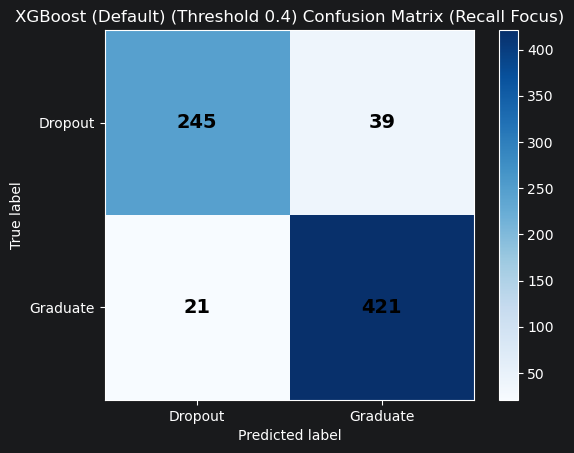

In [19]:

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', dt_preprocessor),
    ('xgb_model', XGBClassifier(
        random_state=42,
        eval_metric='logloss', # suppresses a common XGBoost warning
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = predict_with_threshold(xgb_pipeline, X_test, y_test, threshold=0.4,
                                     model_name='XGBoost (Default)')


***Interpretation:*** The default XGBoost model with a `0.4` threshold achieved the best overall performance so far, with `92% accuracy` and `86% recall` for the `Dropout` class. This makes it the strongest model for identifying students at risk while still maintaining strong performance on `Graduate` predictions. The default model correctly predicted `245 Dropout` and missed `39 Dropout`, it also correctly identified `421 Graduate` and missed `21 Graduate`.


### 8.6.2 Evaluating the model

In [ ]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_xgb, 'XGBoost (Default)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results

***Interpretation:*** The default XGBoost model with a `0.4` threshold achieved a good overall performance so far, with `92% accuracy` and `86% recall` for the `Dropout` class. This makes it the strongest model for identifying students at risk while still maintaining strong performance on `Graduate` predictions.

Next, try to find the best hyperparameter using `RandomizedSearchCV`.


### 8.6.3 RandomizedSearchCV XGBoost Hyperparameter Tuning

XGBoost has a large number of hyperparameters. `RandomizedSearchCV` is more suitable than `GridSearchCV` here because it samples from continuous distributions, covering a much wider search space in the same number of iterations.

Key parameters to tune:
- `n_estimators`: Number of boosting rounds (more = potentially better, but slower)
- `max_depth`: Maximum depth per tree, controls model complexity
- `learning_rate`: Shrinks each tree's contribution, lower = more robust, needs more trees
- `subsample`: Fraction of training rows used per tree, reduces overfitting
- `colsample_bytree`: Fraction of features used per tree,  like `max_features` in RF
- `scale_pos_weight`: Handles class imbalance natively, set to `n_negatives / n_positives`


#### 8.6.3.1 Compute `scale_pos_weight`

`scale_pos_weight` is an XGBoost parameter that handles class imbalance directly, without needing SMOTE. It tells XGBoost to penalize misclassifying the minority class (Dropout, label `0`) more heavily by a factor equal to the ratio of majority to minority samples.


In [ ]:

# Compute class imbalance ratio for scale_pos_weight
n_graduates = (y_train == 1).sum()
n_dropouts  = (y_train == 0).sum()
scale_weight = n_graduates / n_dropouts

print(f"Graduate (majority): {n_graduates}")
print(f"Dropout  (minority): {n_dropouts}")
print(f"scale_pos_weight:    {scale_weight:.2f}")


**Interpretation:** The training set contains `1,767 Graduate` students and `1,137 Dropout` students, giving a class ratio of `1.55`. This indicates a moderate imbalance, so XGBoost can use class weighting to place more emphasis on the minority class and improve Dropout detection.


#### 8.6.3.2 RandomizedSearchCV



In [ ]:
param_distributions = {
    'xgb_model__n_estimators':    randint(50, 500),
    'xgb_model__max_depth':       randint(3, 10),
    'xgb_model__learning_rate':   uniform(0.01, 0.3),
    'xgb_model__subsample':       uniform(0.6, 0.4), # samples from [0.6, 1.0]
    'xgb_model__colsample_bytree': uniform(0.6, 0.4),
    'xgb_model__scale_pos_weight': [1, scale_weight],
}

random_search_xgb = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_xgb.fit(X_train, y_train)

print("Best Parameters:", random_search_xgb.best_params_)
print(f"Best CV Recall (Dropout): {random_search_xgb.best_score_:.4f}")
best_xgb = random_search_xgb.best_estimator_


***Interpretation:*** The RandomizedSearchCV found the best cross-validation `Dropout recall` so far with `0.974`. With a `learning_rate = 0.0203` it means the model learns slowly and carefully. The `n_estimators = 130`, indicates the number of trees, and the `max_depth = 8` a deep tree which lets the model capture non linear relationships. The `subsample = 0.673` and `colsample_bytree = 0.798` the model uses randomness in rows and features which helps to reduces overfitting.

#### 8.6.3.3 Evaluating XGBoost with RandomizedSearchCV

In [ ]:

y_pred_xgb_tuned = predict_with_threshold(best_xgb, X_test, y_test, threshold=0.4, model_name='XGBoost (RandomizedSearchCV)')


***Interpretation:*** The XGBoost with RandomizedSearch did not performed as well as the default XGBoost. This model is misclassifying `54 Dropout` while the default XGBoost missed just `39 Dropouts`. The `recall` for `Dropout` class for this model was `0.81` while for the default XGBoost was `0.86`.

In [ ]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_xgb_tuned,
                                                  'XGBoost (RandomizedSearchCV)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results


***Interpretation:*** The tuned XGBoost with `RandomizedSearchCV` achieved a strong perfromance but did not orperfrom the default XGBoost on the test set. The `Dropout recall` decreased from `0.86` to `0.81`, showing that better cross-validation tuning did not necessarily translate into better performance on test set.

### 8.6.3.4 Tuned XGBoost with SMOTE

Since the default model performed better than the tuned model with `RandomizedSearchCV`, I will use SMOTE with the tuned model to see if it improves the performance compared to the default configuration XGBoost.

In [ ]:
xgb_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', dt_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb_model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        **{k.replace('xgb_model__', ''): v
           for k, v in random_search_xgb.best_params_.items()}
    ))
])

xgb_smote_pipeline.fit(X_train, y_train)

y_pred_xgb_smote = predict_with_threshold(xgb_smote_pipeline, X_test, y_test,
                                           threshold=0.4,
                                           model_name='XGBoost (SMOTE)')


***Interpretation:*** The model slighly improved compared to the tuned XGBoost without `SMOTE`. With `SMOTE`, the model basically have the same `recall` to `82%`, compared to `83%` of the tuned XGBoost. The model correcly identified `233 Dropout` while the XGBoost model without `SMOTE` captured `230 Dropout`, it also missclassified `51 Dropout` while the previous model misclassified `54 Dropout`.

In general this is a good model, but not as good as default XGBoost without `SMOTE`. Next, I will try to improve the default XGBoost classifier using `SMOTE`.

#### 8.6.3.5 Default XGBoost with `SMOTE`

Tuning XGBoost with RandomizedSearchCV did not improve the model compared to the default XGBoost model. However, I haven't test the default configuration with `SMOTE`. This is what I'm going to do in this step.

XGBoost Default (SMOTE) (Threshold 0.4): evaluation results
              precision    recall  f1-score   support

     Dropout       0.90      0.86      0.88       284
    Graduate       0.91      0.94      0.92       442

    accuracy                           0.91       726
   macro avg       0.90      0.90      0.90       726
weighted avg       0.91      0.91      0.91       726



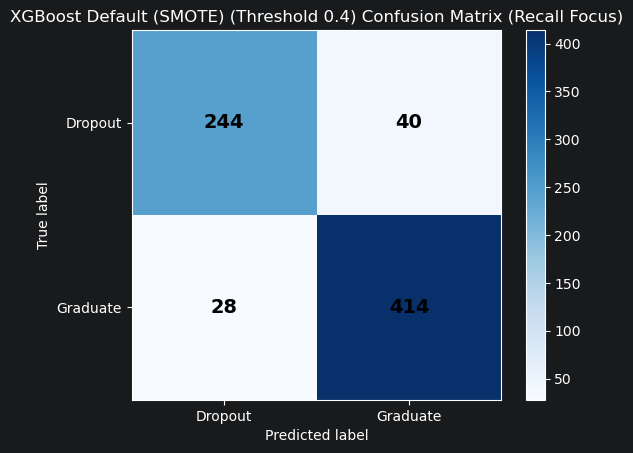

In [29]:
xgb_default_smote_pipeline = ImbPipeline(steps=[
    ('preprocessor', dt_preprocessor),
    ('smote', SMOTE(random_state=42)),
     ('xgb_model', XGBClassifier(
        random_state=42,
        eval_metric='logloss', # suppresses a common XGBoost warning
    ))
])

xgb_default_smote_pipeline.fit(X_train, y_train)

y_pred_xgb_smote = predict_with_threshold(xgb_default_smote_pipeline, X_test, y_test, threshold=0.4, model_name='XGBoost Default (SMOTE)')



***Interpretation:*** This `SMOTE` version is a litter better overall than the previous tuned XGBoost model. It improved the `Dropout` detection improved the `acurracy` to `91%`. This model correctly identified `244 Dropout` students while missing `40 Dropout`. The `Dropout recall` improved to `86%` from `82%` from the tuned model.

This model is a strong choice for `Dropout` prediction.

In [ ]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_xgb_smote,
                                                  'XGBoost Default (SMOTE)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results


## 9.0 Neural Network

After testing Logistic Regression, Decision Tree, KNN, SVM, Random Forest, and XGBoost, I will now train a **Neural Network** using `MLPClassifier` (Multi-Layer Perceptron). A Neural Network learns patterns by passing data through layers of interconnected nodes, where each layer extracts increasingly abstract representations from the input features.


### 9.0.1 Neural Network Preprocessor and Pipeline

Unlike the tree models (Decision Tree, Random Forest, XGBoost), a Neural Network relies on **gradient descent** to learn weights. Gradient descent is sensitive to the scale of input features. For this reason, I will apply `StandardScaler` to numerical features.

I will use the previous preprocessor wich contains `StandardScaler`, called `preprocessor`


In [70]:
nn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('nn_model', MLPClassifier(random_state=42, max_iter=1000, early_stopping=True))
])

nn_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                                  ['age_at_enrollment',
                                                   'cu1_grade', 'cu2_grade',
                                                   'total_approved_units',
                                                   'grade_progression',
                                                   'cu1_approved',
                                                   'cu2_approved']),
                                                 ('binary', 'passthrough',
                                                  ['debtor',
                                                   'tuition_fees_up_to_date',
                                                   'scholarship_holder',
                                                   'any_info_missing',
                                                   'gender']),
                                                 ('categorical',
                                                  OneHotEncoder(drop='first'),
                                                  ['age_group', 'course'])])),
                ('nn_model',
                 MLPClassifier(early_stopping=True, max_iter=1000,
                               random_state=42))])

**Interpretation:** A reused the pipeline thst was created for previous models. The pipeline contains the following: `StandardScaler`, `passthrough` for binary features, `OneHotEncoder` for categorical features, and `max_iter=1000` with   `early_stopping = True` to stop training when validation performance stop improving.


### 9.1 Training the Default Neural Network

I will first train the Neural Network with its default hyperparameters to establish a baseline. By default, `MLPClassifier` uses: One hidden layer with `100 neurons`,`ReLU` activation function, `Adam` optimizer, and a learning rate of `0.001`

This is a relatively small and simple network. The goal at this stage is to assess whether a neural network is competitive with the ensemble or SVM models before investing in deeper tuning.


In [71]:
nn_pipeline.fit(X_train, y_train)

# Print key default parameters
params = nn_pipeline.get_params()
for param, value in sorted(params.items()):
    print(f"{param}: {value}")


memory: None
nn_model: MLPClassifier(early_stopping=True, max_iter=1000, random_state=42)
nn_model__activation: relu
nn_model__alpha: 0.0001
nn_model__batch_size: auto
nn_model__beta_1: 0.9
nn_model__beta_2: 0.999
nn_model__early_stopping: True
nn_model__epsilon: 1e-08
nn_model__hidden_layer_sizes: (100,)
nn_model__learning_rate: constant
nn_model__learning_rate_init: 0.001
nn_model__max_fun: 15000
nn_model__max_iter: 1000
nn_model__momentum: 0.9
nn_model__n_iter_no_change: 10
nn_model__nesterovs_momentum: True
nn_model__power_t: 0.5
nn_model__random_state: 42
nn_model__shuffle: True
nn_model__solver: adam
nn_model__tol: 0.0001
nn_model__validation_fraction: 0.1
nn_model__verbose: False
nn_model__warm_start: False
preprocessor: ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                 ['age_at_enrollment', 'cu1_grade', 'cu2_grade',
                                  'total_approved_units', 'grade_progression',
                                  'cu1

***Interpretation:*** The MLP model is simple with one hidden layer with `100 neurons` and `max_iter = 1000`. I selected `1000` as `max_iter` with `early_stopping= True`. Also, it has `activation = relu`, `solver = adam`, `alpha=0.0001` to reduce overfitting.

## 9.2 Evaluate Default Model

Neural Network (Default) (Threshold 0.4): evaluation results
              precision    recall  f1-score   support

     Dropout       0.87      0.85      0.86       284
    Graduate       0.90      0.92      0.91       442

    accuracy                           0.89       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



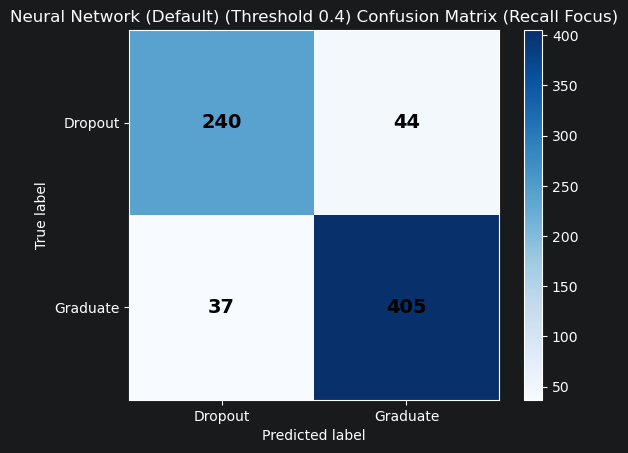

In [72]:
y_pred_nn = predict_with_threshold(nn_pipeline, X_test, y_test, threshold=0.4,
                                    model_name='Neural Network (Default)')


***Interpretation:*** The default Neural Network is strong as the XGBoost which achieved `92% accuracy` while the Neural Network achived `89%`. This Neural Network correctly classified `240 Dropouts` while missing `44`. It also correclty identified `405 Graduate` and missed `37`. For the `Dropout` class, the `precision` was `0.87`, and the `recall` was `0.85`, which is close to the XGBoost that achived `0.86 recall`.

In [73]:
results_models_metrics.append(get_model_metrics(y_test, y_pred_nn, 'Neural Network (Default)'))

temp_results = pd.DataFrame(results_models_metrics).set_index('Model')
temp_results


,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout),Precision (Graduate),Recall (Graduate),F1-Score (Graduate)
Model,,,,,,,
Logistic Regression,0.8650,0.8059,0.8627,0.8333,0.9076,0.8665,0.8866
XGBoost (Default),0.9174,0.9211,0.8627,0.8909,0.9152,0.9525,0.9335
XGBoost (RandomizedSearchCV),0.9036,0.9350,0.8099,0.8679,0.8875,0.9638,0.9241
XGBoost Default (SMOTE),0.9063,0.8971,0.8592,0.8777,0.9119,0.9367,0.9241
Neural Network (Default),0.8898,0.8778,0.8345,0.8556,0.8969,0.9253,0.9109
Neural Network (Default),0.8884,0.8664,0.8451,0.8556,0.9020,0.9163,0.9091


***Interpretation:*** The default Neural Network was one of the best models, just as good as the default XGBoost. Next, I will tune the Neural Network to see if it improves.

### 9.3 Neural Network Hyperparameter Tuning

The architecture and training configuration of a Neural Network have a large impact on performance. I will use `GridSearchCV` to search over the most important hyperparameters, with `recall` for the `Dropout` class as the optimization metric.

Key parameters to tune:
- `hidden_layer_sizes`:Number of layers and neurons per layer
- `activation`: Non-linear function applied at each neuron (`relu` vs `tanh`)
- `alpha`: L2 regularization, higher values reduce overfitting
- `learning_rate_init`: Step size for gradient updates, too large = unstable, too small = slow


In [74]:
param_grid_nn = {
    'nn_model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'nn_model__activation': ['relu', 'tanh'],
    'nn_model__alpha': [0.0001, 0.001, 0.01],
    'nn_model__learning_rate_init': [0.001, 0.01],
}

grid_search_nn = GridSearchCV(
    nn_pipeline,
    param_grid_nn,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search_nn.fit(X_train, y_train)

print("\nBest Parameters:", grid_search_nn.best_params_)
print(f"Best CV Recall (Dropout): {grid_search_nn.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters: {'nn_model__activation': 'tanh', 'nn_model__alpha': 0.0001, 'nn_model__hidden_layer_sizes': (64,), 'nn_model__learning_rate_init': 0.01}
Best CV Recall (Dropout): 0.9649


***Interpretation:*** The best parameter for the Neural Network are `activation = tanh`, `layer_sizes = (64,)` meaning one hidden layer with `64 neurons` was enough. The parameter `alpha = 0.0001` meaning that heavier regularization was not needed. The `learning_rate_init=0.01` meaning the model bearled best with larger starting step size than default. The cross-validation.

## 9.4 Tuned Neural Network Evaluation



Neural Network (Tuned) (Threshold 0.4): evaluation results
              precision    recall  f1-score   support

     Dropout       0.91      0.82      0.86       284
    Graduate       0.89      0.95      0.92       442

    accuracy                           0.90       726
   macro avg       0.90      0.88      0.89       726
weighted avg       0.90      0.90      0.90       726



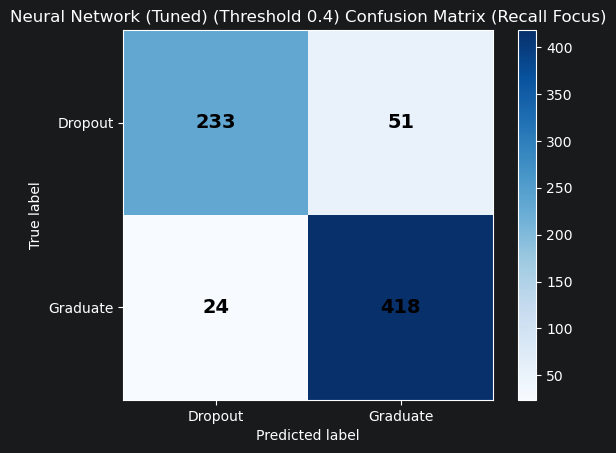

In [82]:
best_nn = grid_search_nn.best_estimator_

y_pred_nn_tuned = predict_with_threshold(best_nn, X_test, y_test, threshold=0.4,
                                          model_name='Neural Network (Tuned)')


***Interpretation:*** The tuned model did not performed as well as the default model. The `Dropout` `recall` fell to `82%` while for the default Neural Network was `85%`. It correctly identified `233 Dropout` while the default identified `240`, also a reduction. This model was better at identifying `Graduate` but not `Dropout`, it correctly identified `418 Graduate` while the default model `405`. But this model is not well suited for detecting `Dropout`.